# Rede Neural (MLP) — Previsão de Churn (Telco) · seleção por validação cruzada

**Autor:** Alessandro Stefani
**Data:** 2026-06-28
**Disciplina:** Tech Challenge — Fase 01 (Produtização de Modelos)
**Etapa:** 2 — Modelagem com Rede Neural
**Descrição:** Versão com **seleção de hiperparâmetros guiada por validação cruzada estratificada** (`StratifiedKFold` no treino de 64%). Cada candidato é avaliado por CV (média ± desvio de PR-AUC) e o melhor é escolhido **sem olhar o val nem o teste**; o val (16%) é reservado para o early stopping do refit e o hold-out de 20% é reportado uma única vez. Engenharia de features, MLP em PyTorch, comparação com baselines (LogReg, RF) e rastreamento no MLflow.

**Dataset:** TelcoCustomerChurn.csv
**Pré-requisito:** decisões de seleção de features e exclusão de leakage definidas no Notebook 01 (incluindo a remoção de `SatisfactionScore`).

## 1. Setup e imports

Imports e constantes globais (`SEED`, `device`, caminho do dataset).

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import copy
import mlflow
import mlflow.pytorch
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt


dataset_path = "../data/raw/TelcoCustomerChurn.csv"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)        # seed do PyTorch


if torch.cuda.is_available():
    device = torch.device("cuda")        # Ubuntu / RTX 5070
elif torch.backends.mps.is_available():
    device = torch.device("mps")         # Mac / Apple GPU
else:
    device = torch.device("cpu")         # CPU (funciona em ambos)

device = torch.device("cpu")            # Mac roda mais rápido em CPU. Estudar motivo posteriormente
print("device:", device)

device: cpu


## 2. Carregamento e seleção de features

Carregar o dataset bruto e aplicar as decisões do Notebook 01: drops (id, leakage, redundância, constantes, alta cardinalidade + `SatisfactionScore`), imputação de negócio (Offer, InternetType) e mapeamento do alvo.

In [2]:
df = pd.read_csv(dataset_path)

print(df.shape)

# imputação de negócio (constante → leakage-safe)
df["Offer"] = df["Offer"].fillna("No offer")
df["InternetType"] = df["InternetType"].fillna("No internet")

y = df["ChurnLabel"].map({"No": 0, "Yes": 1})

USAR_GEO = True   # ⚑ A/B: Lat/Long (inertes no baseline linear; testar se a MLP extrai)

COLS_DROP = [
    "ChurnLabel", "CustomerID",
    "CustomerStatus", "ChurnScore", "ChurnCategory", "ChurnReason",   # leakage
    "CLTV",
    "ZipCode", "SeniorCitizen", "Under30", "TotalRevenue", "InternetService",
    "Country", "State", "Quarter", "City",
    "SatisfactionScore",                       # leakage confirmado
    "Dependents", "ReferredaFriend",           # flags colineares → usar as contínuas
]
if not USAR_GEO:
    COLS_DROP += ["Latitude", "Longitude"]

X = df.drop(columns=COLS_DROP)
print(X.shape)


(7043, 50)
(7043, 31)


## 3. Engenharia de features

Criação de novas variáveis a partir das existentes (ex.: razões, agregações, faixas/bins, interações). Documentar a hipótese de negócio por trás de cada feature criada.

> **A preencher:** features planejadas e a justificativa de cada uma.

In [3]:
# feature nova: valor médio histórico da fatura (razão, não soma → não redundante)
X["valor_medio_fatura"] = X["TotalCharges"] / X["TenureinMonths"]   # tenure min=1, sem div/0

USAR_CONTAGENS = False   # ⚑ A/B: contagens como viés indutivo (binários ABERTOS mantidos)

if USAR_CONTAGENS:
    sim = lambda c: X[c].eq("Yes").astype(int)
    X["qtd_adicionais"] = (sim("OnlineSecurity") + sim("OnlineBackup")
                           + sim("DeviceProtectionPlan") + sim("PremiumTechSupport"))  # coerente ✓
    X["qtd_streaming"]  = sim("StreamingTV") + sim("StreamingMovies") + sim("StreamingMusic")  # fraca
    X["qtd_principais"] = sim("PhoneService") + X["InternetType"].ne("No internet").astype(int)  # pior (apaga internet)

print(X.shape)

(7043, 32)


## 4. Pré-processamento e split

`log1p` nas skewed (mesma base do NB01), identificação dos grupos de colunas e splits estratificados (`SEED=42`). O pré-processamento (OHE + Scaler) é aplicado **independentemente** em cada contexto: por fold na CV (Seção 7) e antes do refit (Seção 9) — sem transformação global intermediária.

**64% - treino** → CV (Seção 8) + treino do refit (Seção 9)
**16% - val** → early stopping do refit — nunca vista pela CV
**20% - teste** → reportado 1× (Seção 9)

In [4]:
# log1p nas skewed — ajusta com base nos próprios valores, pode ser aplicado antes do split
skewed = ["TotalLongDistanceCharges", "AvgMonthlyGBDownload"]
X[skewed] = np.log1p(X[skewed])

# Lista de colunas numéricas e de texto para aplicar nos tratamentos posteriores
num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes("object").columns.tolist()

# Split 1: separa 20% para amostra de teste — idêntico ao NB01 (mesmo SEED/stratify)
X_dev, X_te, y_dev, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# Split 2: separa amostra para validação (early stopping do refit) dos 80% restantes
# treino 64%  → CV (Seção 8) + treino do refit (Seção 9)
# val    16%  → early stopping do refit (Seção 9) — nunca vista pela CV
# teste  20%  → reportado 1× (Seção 9)
X_tr, X_val, y_tr, y_val = train_test_split(X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=SEED)


def to_tensor(Xdf, ys):
    """Converte DataFrame + Series em tensores no device."""
    return (torch.tensor(Xdf.astype(np.float32).values, device=device),
            torch.tensor(ys.values, dtype=torch.float32, device=device).unsqueeze(1))

print("treino:", X_tr.shape, "| val:", X_val.shape, "| teste:", X_te.shape)

treino: (4507, 32) | val: (1127, 32) | teste: (1409, 32)


## 5. Modelo MLP (PyTorch)

Definição da arquitetura (camadas, ativação, dropout/regularização), função de perda (atentar ao desbalanceamento — ex.: `pos_weight` no BCE) e otimizador.

In [5]:
# pos_weight para aplicação posterior na análise de loss (ajuste nos erros por dataset desbalanceado)
pos_weight = torch.tensor([float((y_tr == 0).sum() / (y_tr == 1).sum())], device=device)


class MLP(nn.Module):
    """Arquitetura: blocos Linear -> ReLU -> Dropout; saída em 1 logit (BCEWithLogits)."""
    def __init__(self, in_dim, hidden, dropout):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]              # saída em logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("MLP e loss definidos. pos_weight =", round(pos_weight.item(), 2))

MLP e loss definidos. pos_weight = 2.77


## 6. Funções de treinamento e avaliação

Definição da arquitetura de treino: hiperparâmetros default (`CONFIG`), loop de treino com mini-batches e early stopping (`treinar_mlp`), cálculo de métricas compatíveis com o NB01 (`metricas`) e função de experimentação que empacota treino + avaliação + log no MLflow (`rodar_experimento`).

> **Nota sobre custo de treinamento:** o dataset é pequeno (7.043 linhas), o que mantém o custo absoluto de treinamento baixo mesmo com uma busca de hiperparâmetros mais ampla. Aproveitamos o hardware disponível (GPU local) para explorar arquiteturas e hiperparâmetros mais agressivos sem impacto relevante de tempo/recurso. Ainda assim, mantemos early stopping e limites sensatos para evitar desperdício — trata-se de um trade-off consciente, não de ausência de preocupação com custo.

In [6]:
# Hiperparâmetros de treino (rede pequena p/ tabular pequeno; ajustáveis)
CONFIG = {"hidden": [64, 32],
          "dropout": 0.3,
          "lr": 1e-3,
          "batch": 256,
          "max_epochs": 200,
          "patience": 20}


def val_pr_auc(model, Xv, yv):
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(Xv)).cpu().numpy().ravel()
    return average_precision_score(yv.cpu().numpy().ravel(), p)


def treinar_mlp(Xtr_t, ytr_t, Xval_t, yval_t, cfg, loss_fn):
    """Loop de treino com batching + early stopping (monitora val PR-AUC).
    Restaura os melhores pesos. Retorna (model, history, best_epoch)."""
    torch.manual_seed(SEED)
    model  = MLP(Xtr_t.shape[1], cfg["hidden"], cfg["dropout"]).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=cfg["batch"], shuffle=True)

    best, history, wait = {"prauc": -1, "state": None, "epoch": 0}, [], 0
    for epoch in range(1, cfg["max_epochs"] + 1):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        vp = val_pr_auc(model, Xval_t, yval_t)
        history.append((epoch, loss.item(), vp))
        if vp > best["prauc"]:
            best, wait = {"prauc": vp, "state": copy.deepcopy(model.state_dict()), "epoch": epoch}, 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break
    model.load_state_dict(best["state"])     # restaura o melhor
    return model, history, best["epoch"]


def metricas(model, Xtr_t, ytr_true, Xte_t, yte_true):
    """Mesmo conjunto da logar_metricas do NB01 (comparável)."""
    model.eval()
    with torch.no_grad():
        proba_tr = torch.sigmoid(model(Xtr_t)).cpu().numpy().ravel()
        proba_te = torch.sigmoid(model(Xte_t)).cpu().numpy().ravel()
    pred_tr = (proba_tr >= 0.5).astype(int)
    pred_te = (proba_te >= 0.5).astype(int)
    m = {
        "train_accuracy": accuracy_score(ytr_true, pred_tr),
        "test_accuracy":  accuracy_score(yte_true, pred_te),
        "test_f1_score":  f1_score(yte_true, pred_te),     # <- mesmo nome do NB01
        "test_precision": precision_score(yte_true, pred_te),
        "test_recall":    recall_score(yte_true, pred_te),
        "test_roc_auc":   roc_auc_score(yte_true, proba_te),
        "test_pr_auc":    average_precision_score(yte_true, proba_te),
        "train_pr_auc":   average_precision_score(ytr_true, proba_tr),
    }
    m["overfitting"] = m["train_accuracy"] - m["test_accuracy"]
    m["dif_pr_auc"] = m["train_pr_auc"] - m["test_pr_auc"]
    return m


def rodar_experimento(run_name=None, log_mlflow=True, **overrides):
    """Treina + avalia + (opcional) loga a MLP. Hiperparâmetros via kwargs.

    Usa os tensores já preparados do notebook (Xtr_t, Xval_t, Xte_t).
    Ex.: rodar_experimento(hidden=[128, 64], lr=5e-4, dropout=0.4)
    Qualquer chave não passada usa o default de CONFIG.
    """
    cfg = {**CONFIG, **overrides}                    # overrides em cima do default
    if run_name is None:
        run_name = f"mlp_h{cfg['hidden']}_lr{cfg['lr']}_dp{cfg['dropout']}"

    model, history, best_epoch = treinar_mlp(Xtr_t, ytr_t, Xval_t, yval_t, cfg, loss_fn)
    met = metricas(model, Xtr_t, y_tr.values, Xte_t, y_te.values)

    if log_mlflow:
        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({**cfg, "seed": SEED, "n_features": Xtr_t.shape[1],
                               "usar_geo": USAR_GEO, "usar_contagens": USAR_CONTAGENS,
                               "best_epoch": best_epoch, "dataset": "TelcoCustomerChurn.csv"})
            for epoch, tr_loss, vp in history:
                mlflow.log_metric("train_loss", tr_loss, step=epoch)
                mlflow.log_metric("val_pr_auc", vp, step=epoch)
            mlflow.log_metrics(met)
            ex = X_te.iloc[:5].astype("float32")
            with torch.no_grad():
                out = torch.sigmoid(model(torch.tensor(ex.values, device=device))).cpu().numpy()
            mlflow.pytorch.log_model(model, "model",
                                     signature=infer_signature(ex, out), input_example=ex)

    print(f"{run_name} | best_epoch {best_epoch} | PR-AUC {met['test_pr_auc']:.4f} | recall {met['test_recall']:.4f}")
    
    return model, met

## 7. Validação cruzada estratificada (base da seleção de modelos)

A CV estratificada (`StratifiedKFold`, 5 folds, sobre o **treino de 64%**) é o mecanismo de **seleção**: cada candidato de hiperparâmetros (Seção 8) é avaliado por CV — média ± desvio de PR-AUC — e o melhor é escolhido pela **média da CV**, **sem nunca olhar o teste ou a validação**.

Pré-computamos os folds **uma vez** (`preparar_folds`): em cada fold, `OneHotEncoder` + `StandardScaler` são ajustados **apenas no sub-treino do fold** (sem vazamento) e os DataFrames preparados são reusados por todos os candidatos. Para a MLP, cada fold faz um **sub-split interno (80/20)** para o early stopping. Os baselines (LogReg, RF) treinam no **mesmo sub-treino** → comparação justa.

O **val de 16%** não participa da CV — é reservado exclusivamente para o early stopping do refit (Seção 9). O **teste de 20% permanece intocado** para o reporte final e a análise de custo.

In [7]:
N_SPLITS = 5

modelos_baseline = {
    "LogReg": LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced"),
    "RF": RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                 class_weight="balanced", random_state=SEED, n_jobs=-1),
}


def metricas_sklearn(model, Xtr, ytr, Xte, yte):
    """Mesmo conjunto de metricas da MLP, para modelos sklearn (comparavel)."""
    proba_tr = model.predict_proba(Xtr)[:, 1]
    proba_te = model.predict_proba(Xte)[:, 1]
    pred_tr = (proba_tr >= 0.5).astype(int)
    pred_te = (proba_te >= 0.5).astype(int)
    m = {
        "train_accuracy": accuracy_score(ytr, pred_tr),
        "test_accuracy":  accuracy_score(yte, pred_te),
        "test_f1_score":  f1_score(yte, pred_te),
        "test_precision": precision_score(yte, pred_te),
        "test_recall":    recall_score(yte, pred_te),
        "test_roc_auc":   roc_auc_score(yte, proba_te),
        "test_pr_auc":    average_precision_score(yte, proba_te),
        "train_pr_auc":   average_precision_score(ytr, proba_tr),
    }
    m["overfitting"] = m["train_accuracy"] - m["test_accuracy"]
    m["dif_pr_auc"] = m["train_pr_auc"] - m["test_pr_auc"]
    return m


def preparar_folds(X_dev, y_dev, num_cols, cat_cols, n_splits=N_SPLITS):
    """Pre-computa os folds da CV. OHE+Scaler ajustados so no sub-treino de cada fold.
    Retorna lista de dicts com os DataFrames ja preparados (reusados por todos os candidatos)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    folds = []
    for idx_tr, idx_te in skf.split(X_dev, y_dev):
        Xf_dev, Xf_te = X_dev.iloc[idx_tr], X_dev.iloc[idx_te]
        yf_dev, yf_te = y_dev.iloc[idx_tr], y_dev.iloc[idx_te]

        # sub-split interno p/ early stopping da MLP (80/20 do treino do fold)
        Xf_tr, Xf_val, yf_tr, yf_val = train_test_split(
            Xf_dev, yf_dev, test_size=0.2, stratify=yf_dev, random_state=SEED)

        ohe_f = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False).fit(Xf_tr[cat_cols])
        scaler_f = StandardScaler().fit(Xf_tr[num_cols])
        cat_f = ohe_f.get_feature_names_out(cat_cols)

        def prep(d):
            n = pd.DataFrame(scaler_f.transform(d[num_cols]), columns=num_cols, index=d.index)
            c = pd.DataFrame(ohe_f.transform(d[cat_cols]), columns=cat_f, index=d.index)
            return pd.concat([n, c], axis=1)

        folds.append({"Xtr": prep(Xf_tr), "ytr": yf_tr,
                      "Xval": prep(Xf_val), "yval": yf_val,
                      "Xte": prep(Xf_te),  "yte": yf_te})
    return folds


def cv_mlp(folds, cfg):
    """Treina a MLP com `cfg` em cada fold pre-computado. Retorna lista de metricas (1 por fold)."""
    out = []
    for f in folds:
        pw = torch.tensor([float((f["ytr"] == 0).sum() / (f["ytr"] == 1).sum())], device=device)
        loss_f = nn.BCEWithLogitsLoss(pos_weight=pw)
        Xtr_t, ytr_t = to_tensor(f["Xtr"], f["ytr"])
        Xval_t, yval_t = to_tensor(f["Xval"], f["yval"])
        Xte_t, _ = to_tensor(f["Xte"], f["yte"])
        model_f, _, _ = treinar_mlp(Xtr_t, ytr_t, Xval_t, yval_t, cfg, loss_f)
        out.append(metricas(model_f, Xtr_t, f["ytr"].values, Xte_t, f["yte"].values))
    return out


def cv_baselines(folds):
    """Avalia os baselines sklearn nos mesmos folds/sub-treino da MLP (comparacao justa)."""
    res = {nome: [] for nome in modelos_baseline}
    for f in folds:
        for nome, mod in modelos_baseline.items():
            m = clone(mod).fit(f["Xtr"], f["ytr"])
            res[nome].append(metricas_sklearn(m, f["Xtr"], f["ytr"], f["Xte"], f["yte"]))
    return res


def agregar_cv(folds_met):
    """Media +/- desvio das metricas ao longo dos folds: dict -> {metrica: (mean, std)}."""
    chaves = folds_met[0].keys()
    return {k: (float(np.mean([d[k] for d in folds_met])),
               float(np.std([d[k] for d in folds_met]))) for k in chaves}

## 8. Busca de hiperparâmetros por CV + registro no MLflow

Cada candidato da grade é avaliado **por CV no treino de 64%** (Seção 7) e registrado no MLflow com a **média ± desvio** das métricas (`cv_*_mean`, `cv_*_std`). O melhor é escolhido pela **média de PR-AUC na CV** — o val (16%) e o teste (20%) **nunca participam da seleção**.

O loop é **explícito sobre a grade** (sem linhas comentadas): um `Restart & Run All` após apagar `mlruns/` reproduz a tabela inteira. Os folds são pré-computados uma vez e reusados por todos os candidatos (custo controlado).

In [8]:
mlflow.set_experiment("telco_churn_mlp")

# Grade de candidatos (overrides sobre CONFIG). Loop reproduzivel: gera a tabela inteira num passe.
CANDIDATOS = {
    "mlp_padrao":       {},
    "mlp_ba128":        {"batch": 128},
    "mlp_ba64":         {"batch": 64},
    "mlp_lr1e-4":       {"lr": 1e-4},
    "mlp_lr1e-4_ba128": {"lr": 1e-4, "batch": 128},
    "mlp_lr1e-4_ba64":  {"lr": 1e-4, "batch": 64},
    "mlp_hi128-64-32":  {"hidden": [128, 64, 32], "batch": 128},
    "mlp_hi256-128-64": {"hidden": [256, 128, 64], "batch": 128},
    "mlp_pa50":         {"patience": 50},
}

folds = preparar_folds(X_tr, y_tr, num_cols, cat_cols)
print(f"Stratified {N_SPLITS}-Fold CV no treino ({len(X_tr)} amostras) | {len(CANDIDATOS)} candidatos\n")

cv_mlp_result = {}
for nome, ov in CANDIDATOS.items():
    cfg = {**CONFIG, **ov}
    folds_met = cv_mlp(folds, cfg)
    cv_mlp_result[nome] = folds_met
    agg = agregar_cv(folds_met)
    with mlflow.start_run(run_name=f"cv_{nome}"):
        mlflow.log_params({**cfg, "seed": SEED, "n_splits": N_SPLITS,
                           "usar_geo": USAR_GEO, "usar_contagens": USAR_CONTAGENS,
                           "selecao": "cv", "dataset": "TelcoCustomerChurn.csv"})
        mlflow.log_metrics({f"cv_{k}_mean": v[0] for k, v in agg.items()})
        mlflow.log_metrics({f"cv_{k}_std": v[1] for k, v in agg.items()})
    pr = agg["test_pr_auc"]
    print(f"  {nome:<18} CV PR-AUC = {pr[0]:.4f} +/- {pr[1]:.4f}")

# baselines avaliados por CV nos mesmos folds (uma vez)
cv_base_result = cv_baselines(folds)

2026/06/29 08:47:07 INFO mlflow.tracking.fluent: Experiment with name 'telco_churn_mlp' does not exist. Creating a new experiment.


Stratified 5-Fold CV no treino (4507 amostras) | 9 candidatos

  mlp_padrao         CV PR-AUC = 0.7660 +/- 0.0121
  mlp_ba128          CV PR-AUC = 0.7665 +/- 0.0157
  mlp_ba64           CV PR-AUC = 0.7676 +/- 0.0122
  mlp_lr1e-4         CV PR-AUC = 0.7599 +/- 0.0141
  mlp_lr1e-4_ba128   CV PR-AUC = 0.7638 +/- 0.0121
  mlp_lr1e-4_ba64    CV PR-AUC = 0.7633 +/- 0.0109
  mlp_hi128-64-32    CV PR-AUC = 0.7609 +/- 0.0119
  mlp_hi256-128-64   CV PR-AUC = 0.7591 +/- 0.0139
  mlp_pa50           CV PR-AUC = 0.7660 +/- 0.0121


In [9]:
def tabela_cv(cv_mlp_result, cv_base_result):
    """Tabela media +/- desvio (CV) por modelo, ordenada pela media de PR-AUC."""
    metricas_cv = ["test_pr_auc", "dif_pr_auc", "test_roc_auc",
                   "test_recall", "test_precision", "test_f1_score", "test_accuracy"]
    linhas = {}
    for nome, fm in {**cv_mlp_result, **cv_base_result}.items():
        agg = agregar_cv(fm)
        linhas[nome] = {m: f"{agg[m][0]:.4f} +/- {agg[m][1]:.4f}" for m in metricas_cv}
    df = pd.DataFrame(linhas).T
    ordem = (df["test_pr_auc"].str.split(" ").str[0].astype(float)
             .sort_values(ascending=False).index)
    return df.loc[ordem]


display(tabela_cv(cv_mlp_result, cv_base_result))

# Melhor candidato pela MEDIA de PR-AUC na CV (o teste nunca participa da selecao)
melhor = max(cv_mlp_result, key=lambda n: np.mean([d["test_pr_auc"] for d in cv_mlp_result[n]]))
MELHOR_CFG = {**CONFIG, **CANDIDATOS[melhor]}
melhor_prauc = agregar_cv(cv_mlp_result[melhor])["test_pr_auc"]
print(f"\n-> Melhor candidato por CV: {melhor}  |  CV PR-AUC = {melhor_prauc[0]:.4f} +/- {melhor_prauc[1]:.4f}")
print(f"   config: {MELHOR_CFG}")

,test_pr_auc,dif_pr_auc,test_roc_auc,test_recall,test_precision,test_f1_score,test_accuracy
mlp_ba64,0.7676 +/- 0.0122,0.0461 +/- 0.0116,0.8991 +/- 0.0100,0.8395 +/- 0.0302,0.5978 +/- 0.0162,0.6981 +/- 0.0182,0.8074 +/- 0.0113
mlp_ba128,0.7665 +/- 0.0157,0.0387 +/- 0.0159,0.8971 +/- 0.0099,0.8294 +/- 0.0404,0.5981 +/- 0.0205,0.6943 +/- 0.0183,0.8063 +/- 0.0126
mlp_padrao,0.7660 +/- 0.0121,0.0514 +/- 0.0136,0.8984 +/- 0.0093,0.8353 +/- 0.0323,0.6060 +/- 0.0176,0.7020 +/- 0.0166,0.8118 +/- 0.0113
mlp_pa50,0.7660 +/- 0.0121,0.0514 +/- 0.0136,0.8984 +/- 0.0093,0.8353 +/- 0.0323,0.6060 +/- 0.0176,0.7020 +/- 0.0166,0.8118 +/- 0.0113
LogReg,0.7641 +/- 0.0079,0.0094 +/- 0.0092,0.8976 +/- 0.0073,0.8462 +/- 0.0179,0.5801 +/- 0.0140,0.6882 +/- 0.0137,0.7965 +/- 0.0100
mlp_lr1e-4_ba128,0.7638 +/- 0.0121,0.0325 +/- 0.0158,0.8966 +/- 0.0093,0.8294 +/- 0.0292,0.5993 +/- 0.0151,0.6956 +/- 0.0154,0.8074 +/- 0.0098
mlp_lr1e-4_ba64,0.7633 +/- 0.0109,0.0287 +/- 0.0220,0.8961 +/- 0.0082,0.8269 +/- 0.0257,0.5960 +/- 0.0130,0.6925 +/- 0.0131,0.8052 +/- 0.0085
mlp_hi128-64-32,0.7609 +/- 0.0119,0.0523 +/- 0.0146,0.8964 +/- 0.0091,0.8269 +/- 0.0325,0.5858 +/- 0.0175,0.6853 +/- 0.0150,0.7985 +/- 0.0107
mlp_lr1e-4,0.7599 +/- 0.0141,0.0262 +/- 0.0172,0.8944 +/- 0.0101,0.8345 +/- 0.0267,0.5890 +/- 0.0143,0.6904 +/- 0.0155,0.8014 +/- 0.0101
mlp_hi256-128-64,0.7591 +/- 0.0139,0.0621 +/- 0.0163,0.8953 +/- 0.0093,0.8352 +/- 0.0396,0.5910 +/- 0.0279,0.6911 +/- 0.0167,0.8016 +/- 0.0162



-> Melhor candidato por CV: mlp_ba64  |  CV PR-AUC = 0.7676 +/- 0.0122
   config: {'hidden': [64, 32], 'dropout': 0.3, 'lr': 0.001, 'batch': 64, 'max_epochs': 200, 'patience': 20}


## 9. Modelo final — refit do melhor candidato no hold-out

Com o vencedor escolhido pela CV (Seção 8), ajustamos o `OneHotEncoder` e o `StandardScaler` no **treino de 64%** (independentes dos ajustes feitos por fold na CV) e treinamos a versão final com early stopping no **val de 16%** — que não participou da seleção. A avaliação é feita **uma única vez** no **teste de 20%**.

O modelo final é registrado no MLflow (`mlp_final_*`) com parâmetros, métricas de hold-out, `signature` e `input_example`.

In [10]:
# OHE + Scaler ajustados no treino (independentes da CV)
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
scaler = StandardScaler()
ohe.fit(X_tr[cat_cols])
scaler.fit(X_tr[num_cols])
cat_names = ohe.get_feature_names_out(cat_cols)


def preparar(parte):
    """Aplica o pré-processamento ajustado no treino. Retorna DataFrame."""
    num = pd.DataFrame(scaler.transform(parte[num_cols]), columns=num_cols, index=parte.index)
    cat = pd.DataFrame(ohe.transform(parte[cat_cols]), columns=cat_names, index=parte.index)
    return pd.concat([num, cat], axis=1)


X_tr  = preparar(X_tr)
X_val = preparar(X_val)
X_te  = preparar(X_te)

Xtr_t,  ytr_t  = to_tensor(X_tr,  y_tr)
Xval_t, yval_t = to_tensor(X_val, y_val)
Xte_t,  yte_t  = to_tensor(X_te,  y_te)

print("features:", Xtr_t.shape[1], "| treino:", tuple(Xtr_t.shape),
      "| val:", tuple(Xval_t.shape), "| teste:", tuple(Xte_t.shape))

features: 40 | treino: (4507, 40) | val: (1127, 40) | teste: (1409, 40)


In [11]:
model_final, met_final = rodar_experimento(
    **CANDIDATOS[melhor], run_name=f"mlp_final_{melhor}", log_mlflow=True)

print("\nMetricas no hold-out (teste 20%) do modelo final escolhido por CV:")
for k, v in met_final.items():
    print(f"  {k:<16}{v:.4f}")

mlp_final_mlp_ba64 | best_epoch 16 | PR-AUC 0.7805 | recall 0.8636

Metricas no hold-out (teste 20%) do modelo final escolhido por CV:
  train_accuracy  0.8363
  test_accuracy   0.8233
  test_f1_score   0.7218
  test_precision  0.6200
  test_recall     0.8636
  test_roc_auc    0.9115
  test_pr_auc     0.7805
  train_pr_auc    0.8179
  overfitting     0.0130
  dif_pr_auc      0.0374


## 10. Análise de trade-off de custo (FP × FN)

Nem todos os erros custam igual. Em churn:
- **FN (churn perdido):** cliente sai sem ação → perda de receita futura
- **FP (alarme falso):** campanha de retenção desnecessária → custo operacional

O threshold padrão (0.5) ignora essa assimetria. Varremos thresholds para encontrar o ponto que **minimiza o custo total** = FP × custo_fp + FN × custo_fn.

**Premissas:** razão FN/FP = 10:1 — cada churn perdido custa ~10× uma campanha desnecessária. Os valores absolutos importam menos que a razão.

Para comparação justa, todos os modelos (MLP, LogReg, RF) são treinados no **mesmo conjunto de treino** (64%) e avaliados no **mesmo teste** (20%), com o mesmo pré-processamento.

In [12]:

# ── Premissas de custo (ajustáveis) ────────────────────────────────
# Razão FN/FP = 10:1 — cada churn perdido custa ~10× uma campanha desnecessária.
# Os valores absolutos importam menos que a razão.
CUSTO_FN = 500   # perder o cliente (receita futura)
CUSTO_FP = 50    # campanha de retenção em quem não ia sair


def custo_por_threshold(y_true, y_proba, custo_fn=CUSTO_FN, custo_fp=CUSTO_FP):
    """Varre thresholds: para cada um, calcula FP, FN e custo total."""
    y_true, y_proba = np.asarray(y_true).ravel(), np.asarray(y_proba).ravel()
    rows = []
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_proba >= t).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        custo = fp * custo_fp + fn * custo_fn
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1v  = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        rows.append({"threshold": round(t, 4), "tp": tp, "fp": fp, "fn": fn,
                      "custo_total": custo, "precision": round(prec, 4),
                      "recall": round(rec, 4), "f1": round(f1v, 4)})
    return pd.DataFrame(rows)


def plotar_custo(df_custo, titulo=""):
    """Custo total × threshold (esq.) + FP vs FN (dir.). Retorna (threshold_ótimo, custo_mínimo)."""
    idx = df_custo["custo_total"].idxmin()
    t_opt, c_opt = df_custo.loc[idx, "threshold"], df_custo.loc[idx, "custo_total"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(df_custo["threshold"], df_custo["custo_total"], lw=2)
    ax1.axvline(t_opt, color="red", ls="--", lw=1)
    ax1.scatter(t_opt, c_opt, color="red", zorder=5, s=60,
                label=f"ótimo: t={t_opt:.2f}  →  ${c_opt:,.0f}")
    ax1.axvline(0.5, color="gray", ls=":", alpha=0.5, label="t = 0.50 (padrão)")
    ax1.set(xlabel="Threshold", ylabel="Custo total ($)", title=f"Custo total — {titulo}")
    ax1.legend(fontsize=9)

    ax2.plot(df_custo["threshold"], df_custo["fp"],
             label="FP (campanha desnecessária)", color="orange")
    ax2.plot(df_custo["threshold"], df_custo["fn"],
             label="FN (churn perdido)", color="red")
    ax2.axvline(t_opt, color="gray", ls="--", alpha=0.4)
    ax2.set(xlabel="Threshold", ylabel="Quantidade", title=f"FP vs FN — {titulo}")
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    return t_opt, c_opt


def comparar_custos(modelos_proba, y_true, custo_fn=CUSTO_FN, custo_fp=CUSTO_FP):
    """Tabela-resumo: threshold ótimo + métricas no ótimo vs no padrão (0.5), por modelo."""
    resumos = []
    for nome, proba in modelos_proba.items():
        df = custo_por_threshold(y_true, proba, custo_fn, custo_fp)
        best = df.loc[df["custo_total"].idxmin()]
        at50 = df.iloc[(df["threshold"] - 0.5).abs().argsort().iloc[0]]
        resumos.append({
            "modelo": nome,
            "t_otimo": best["threshold"], "custo_otimo": int(best["custo_total"]),
            "recall_otimo": best["recall"], "prec_otimo": best["precision"],
            "f1_otimo": best["f1"],
            "custo_t05": int(at50["custo_total"]),
            "recall_t05": at50["recall"], "prec_t05": at50["precision"],
        })
    return pd.DataFrame(resumos).set_index("modelo")

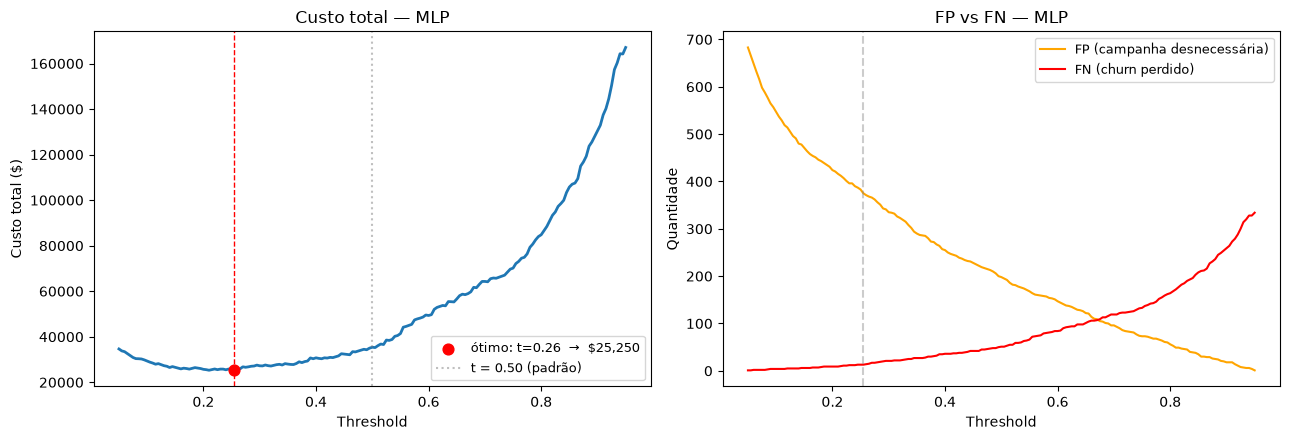

  -> MLP: threshold otimo = 0.26, custo = $25,250



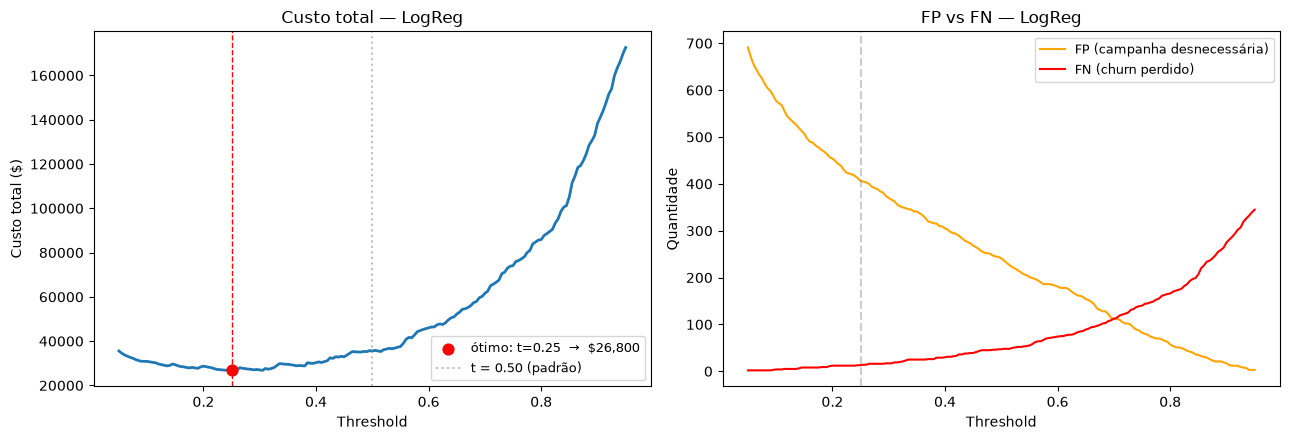

  -> LogReg: threshold otimo = 0.25, custo = $26,800



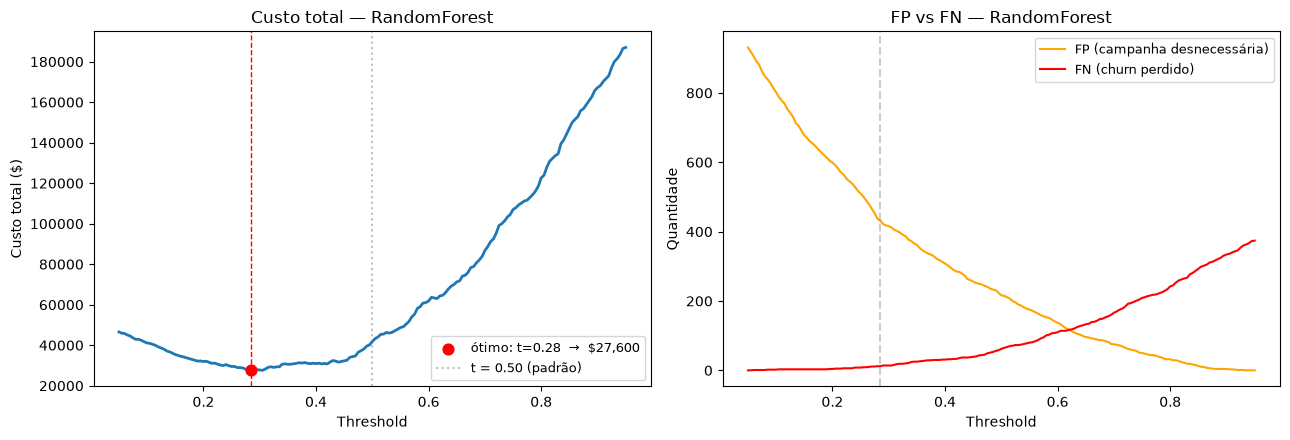

  -> RandomForest: threshold otimo = 0.28, custo = $27,600



,t_otimo,custo_otimo,recall_otimo,prec_otimo,f1_otimo,custo_t05,recall_t05,prec_t05
modelo,,,,,,,,
MLP,0.255,25250,0.9652,0.4905,0.6505,35400,0.8636,0.6200
LogReg,0.250,26800,0.9652,0.4707,0.6328,35550,0.8743,0.5757
RandomForest,0.285,27600,0.9679,0.4559,0.6199,41800,0.8342,0.5909


In [13]:
# Probas no teste (todos no mesmo X_tr / X_te -> comparacao justa)
lr = LogisticRegression(random_state=SEED, max_iter=1000, class_weight="balanced")
lr.fit(X_tr, y_tr)
proba_lr = lr.predict_proba(X_te)[:, 1]

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                            class_weight="balanced", random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)
proba_rf = rf.predict_proba(X_te)[:, 1]

# MLP final (melhor por CV, ja treinada na Secao 9) — reusa o modelo, nao retreina
model_final.eval()
with torch.no_grad():
    proba_mlp = torch.sigmoid(model_final(Xte_t)).cpu().numpy().ravel()

y_true = y_te.values.ravel()

# Graficos por modelo
for nome, proba in [("MLP", proba_mlp), ("LogReg", proba_lr), ("RandomForest", proba_rf)]:
    df_c = custo_por_threshold(y_true, proba)
    t, c = plotar_custo(df_c, nome)
    print(f"  -> {nome}: threshold otimo = {t:.2f}, custo = ${c:,.0f}\n")

# Tabela comparativa: threshold otimo vs padrao (0.5)
modelos_proba = {"MLP": proba_mlp, "LogReg": proba_lr, "RandomForest": proba_rf}
display(comparar_custos(modelos_proba, y_true))

## 11. Conclusões e próximos passos

**Conclusões**

A seleção de hiperparâmetros é **guiada por validação cruzada estratificada** (Seção 8): cada candidato é avaliado por `StratifiedKFold` (5 folds) no **treino de 64%**, e o vencedor é escolhido pela **média de PR-AUC na CV** — sem espiar o val (reservado para o early stopping do refit) nem o teste. O hold-out de 20% é reportado **uma única vez** (Seção 9), isolando completamente a seleção de hiperparâmetros da avaliação final.

O candidato vencedor por CV foi a `mlp_ba64` (arquitetura `[64, 32]`, batch 64 — CV PR-AUC **0,7676 ± 0,0122**), com **0,7805** no hold-out. Os três modelos reais (MLP, LogReg, RF) operam na mesma faixa (~0,75–0,77 de PR-AUC na CV), com desvios-padrão baixos entre folds — confirmando que, para este dataset tabular de ~7 mil linhas, o sinal preditivo está nas **features** (especialmente `tenure` e variáveis de contrato), não na complexidade do modelo. A consistência entre a média da CV e o valor do hold-out reforça a confiança nas estimativas.

A métrica `dif_pr_auc` (PR-AUC treino − teste) confirma-se como o melhor indicador de overfitting: na CV, o Random Forest decora mais (~0,083) que a MLP (~0,03–0,06, conforme a configuração) e a Regressão Logística (~0,009). Com a separação limpa entre CV e refit, a CV escolheu a rede mais simples (`[64, 32]`) em vez da maior (`[128, 64, 32]`) — resultado coerente com o princípio de que, com menos dados por fold, modelos menores generalizam melhor. O vencedor apresenta `dif_pr_auc` de 0,037 no hold-out — overfit baixo e controlado.

A análise de custo (Seção 10) mostra que o **threshold operacional importa mais que a escolha do modelo**. Com razão FN/FP de 10:1, o threshold ótimo cai bem abaixo de 0,5 (MLP ~0,26, LogReg ~0,25, RF ~0,28), reduzindo o custo total em ~29–34% frente ao padrão. No ponto ótimo a MLP é a mais barata ($25.250, contra $26.800 da LogReg e $27.600 do RF), mas a diferença entre modelos (~9%) é pequena perto do ganho de ajustar o threshold (~29% na MLP).

**Limitações**

O dataset é um snapshot transversal — sem dados longitudinais, não é possível modelar trajetórias de comportamento. Boa parte do sinal vem de `tenure` e correlatas, o que torna o modelo sensível a drift nessa distribuição. O dataset não registra campanhas de retenção: o modelo prevê churn *sem intervenção*, não *apesar* dela. Por fim, `SatisfactionScore` foi confirmada como data leakage (PR-AUC salta para ~0,98 ao incluí-la) e excluída de todos os modelos.

**Próximos passos (Etapas 3 e 4)**

Refatorar os notebooks para módulos em `src/churn/` com pipeline reprodutível (sklearn + transformadores custom), testes pytest e API FastAPI (`/predict`, `/health`). A Etapa 4 inclui Model Card, documento de arquitetura de deploy (batch vs real-time), plano de monitoramento e vídeo STAR.